<a href="https://colab.research.google.com/github/ANJALICHAMOLI/Deep-Learning/blob/main/binaryclas_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rjmanoj/credit-card-customer-churn-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'credit-card-customer-churn-prediction' dataset.
Path to dataset files: /kaggle/input/credit-card-customer-churn-prediction


In [ ]:
import os

print(os.listdir(path))

['Churn_Modelling.csv']


In [ ]:
df = pd.read_csv(path + '/Churn_Modelling.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# 3. PREPROCESSING
df =df.drop(columns=['RowNumber','CustomerId','Surname'])


In [ ]:
df =pd.get_dummies(df,columns=['Geography','Gender'],drop_first =True)

In [ ]:
X = df.drop(columns=['Exited'])
y = df['Exited']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [ ]:
# 5. FEATURE SCALING

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

model.add(Dense(11, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(11, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [ ]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7602 - loss: 0.5520 - val_accuracy: 0.7981 - val_loss: 0.4868
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7997 - loss: 0.4611 - val_accuracy: 0.8006 - val_loss: 0.4472
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8103 - loss: 0.4340 - val_accuracy: 0.8112 - val_loss: 0.4361
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8164 - loss: 0.4235 - val_accuracy: 0.8138 - val_loss: 0.4299
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8195 - loss: 0.4153 - val_accuracy: 0.8163 - val_loss: 0.4223
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8255 - loss: 0.4053 - val_accuracy: 0.8213 - val_loss: 0.4128
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8344 - loss: 0.3924 - val_accuracy: 0.8281 - val_loss: 0.3990
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8408 - loss: 0.3772 - val_accu

In [ ]:
model.layers[1].get_weights()

[array([[ 6.51269734e-01, -2.88246125e-01,  1.07985348e-01,
         -1.31446123e-01, -1.53607264e-01,  2.18791887e-01,
         -3.06748927e-01, -1.20037891e-01,  3.87846917e-01,
          2.34195277e-01, -3.92777383e-01],
        [-1.00749612e-01,  5.06320596e-01, -9.68247841e-05,
         -1.26357108e-01,  2.99144387e-01,  6.35945022e-01,
         -4.04343665e-01,  2.12001219e-01, -5.95231615e-02,
         -6.75217152e-01,  2.61640161e-01],
        [-5.44737279e-01, -1.95833713e-01,  6.40770972e-01,
         -3.52949812e-03,  4.88581866e-01, -2.54366547e-02,
         -6.26533747e-01,  4.33810830e-01,  3.82718652e-01,
          3.08541387e-01, -4.35611457e-02],
        [ 3.62386256e-01,  4.60332818e-02, -1.01532657e-02,
         -5.63187718e-01,  2.47757822e-01, -2.45822787e-01,
          9.26395431e-02,  2.67165173e-02, -3.85977536e-01,
          6.51667774e-01,  1.80586636e-01],
        [ 2.06994697e-01,  1.86823104e-02,  5.00985801e-01,
         -1.10055673e+00, -2.57170469e-01,  

In [ ]:
y_log =model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
# Convert probabilities to 0/1
y_pred =np.where(y_log > 0.5,1,0)

In [ ]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8595

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
history.history

{'accuracy': [0.7601562738418579,
  0.7996875047683716,
  0.8103125095367432,
  0.81640625,
  0.819531261920929,
  0.8254687786102295,
  0.8343750238418579,
  0.8407812714576721,
  0.846875011920929,
  0.8504687547683716,
  0.8532812595367432,
  0.8539062738418579,
  0.854687511920929,
  0.8553125262260437,
  0.8557812571525574,
  0.8560937643051147,
  0.8565624952316284,
  0.8556249737739563,
  0.8567187786102295,
  0.8570312261581421,
  0.8565624952316284,
  0.8596875071525574,
  0.8578125238418579,
  0.8582812547683716,
  0.8598437309265137,
  0.858593761920929,
  0.8604687452316284,
  0.8596875071525574,
  0.8600000143051147,
  0.8592187762260437,
  0.8621875047683716,
  0.859375,
  0.8614062666893005,
  0.8615624904632568,
  0.8626562356948853,
  0.8615624904632568,
  0.8617187738418579,
  0.8621875047683716,
  0.862500011920929,
  0.8612499833106995,
  0.8606250286102295,
  0.8623437285423279,
  0.8621875047683716,
  0.8629687428474426,
  0.8621875047683716,
  0.8626562356948853,

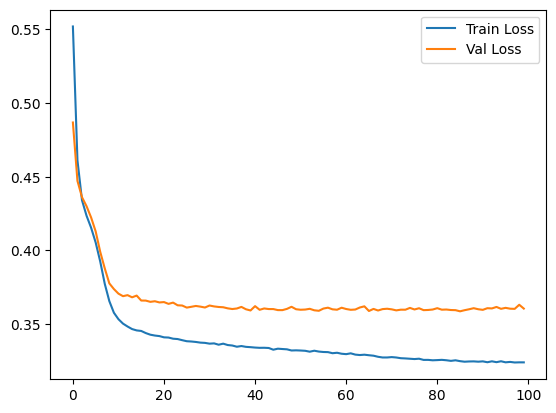

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()